<a href="https://colab.research.google.com/github/sanjanapstech-ui/Word2Vec/blob/main/word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word2Vec with Gensim

Introduces Gensim's `Word2Vec` model and demonstrates its use, following the
structure of the official Gensim word2vec tutorial:

1. Review: Bag-of-words
2. Introducing the Word2Vec model
3. Word2Vec demo on a small self-built dataset
4. Training your own model
5. Storing and loading models
6. Training parameters (`min_count`, `vector_size`, `workers`)
7. Memory requirements
8. Evaluating (word analogies + word pair similarity)
9. Online training / resuming training
10. Training loss computation
11. Visualizing embeddings (t-SNE)


In [7]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.4 MB/s eta 0:00:00


## Review: Bag-of-words

*(Skip this if you're already comfortable with bag-of-words.)*

The bag-of-words model transforms each document into a fixed-length vector of
word counts. For example:

- "John likes to watch movies. Mary likes movies too."
- "John also likes to watch football games. Mary hates football."

become vectors like `[1, 2, 1, 1, 2, 1, 1, 0, 0, 0, 0]` and
`[1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 1]`, where each position counts how many
times a specific word occurred.

Two weaknesses this has:
1. **Word order is lost** — "John likes Mary" and "Mary likes John" produce
   identical vectors.
2. **No notion of meaning** — the model doesn't know "good" and "great" are
   related. Word2Vec fixes this second problem.


## Introducing the Word2Vec model

Word2Vec embeds words into a lower-dimensional vector space using a shallow
neural network, so that words with similar meaning end up with similar
vectors. There are two architectures, and Gensim's `Word2Vec` class
implements both:

1. **Skip-gram (SG)** — given an input word, predict its surrounding context words.
2. **Continuous Bag-of-Words (CBOW)** — given the surrounding context words, predict the center word.

The skip-gram model is a 1-hidden-layer neural network: a one-hot input word
goes through a projection layer to the hidden layer, and those projection
weights become the word embeddings. A 300-neuron hidden layer gives
300-dimensional word vectors.


## Word2Vec demo (small, self-contained dataset)

To see what Word2Vec can do before training our "real" model later in this
notebook, we build a tiny hand-written corpus ourselves — no download
required. It mixes two loose themes (**vehicles** and **royalty**) so we
have at least two clusters of related words to explore.

This corpus is far too small to produce high-quality embeddings (that's
what the Google News vectors are for), but it's enough to demonstrate the
API: looking up vectors, computing similarity, `most_similar`, and
`doesnt_match`.


In [2]:
# A small, self-contained corpus -- no download needed.
# We build it programmatically by combining subjects/verbs/objects from two
# themes so the same words co-occur often enough for Word2Vec to learn
# something from them.
import itertools
import random

random.seed(0)

vehicle_subjects = ['car', 'bicycle', 'airplane', 'train', 'bus', 'truck', 'motorcycle', 'boat', 'ship']
vehicle_verbs = ['travels', 'moves', 'carries passengers', 'transports goods', 'races', 'crosses the country']
vehicle_places = ['on the highway', 'through the city', 'across the country', 'near the station', 'along the coast']

royalty_subjects = ['king', 'queen', 'prince', 'princess', 'duke', 'duchess', 'emperor', 'monarch']
royalty_verbs = ['rules', 'reigns over', 'governs', 'presides over', 'protects']
royalty_places = ['the kingdom', 'the castle', 'the palace', 'the royal court', 'the empire']

sentences = []
for subj, verb, place in itertools.product(vehicle_subjects, vehicle_verbs, vehicle_places):
    sentences.append(f"the {subj} {verb} {place}")
for subj, verb, place in itertools.product(royalty_subjects, royalty_verbs, royalty_places):
    sentences.append(f"the {subj} {verb} {place}")

random.shuffle(sentences)
print(f"{len(sentences)} sentences, e.g.:")
for s in sentences[:5]:
    print(" -", s)

tokenized_sentences = [s.split() for s in sentences]

470 sentences, e.g.:
 - the motorcycle moves on the highway
 - the truck crosses the country across the country
 - the princess rules the kingdom
 - the prince rules the royal court
 - the train crosses the country through the city


In [8]:
from gensim.models import Word2Vec

# Small vector_size and a low min_count since this is a tiny corpus.
demo_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=50,
    window=4,
    min_count=1,
    workers=4,
    epochs=50,
)
wv = demo_model.wv
print(f"Vocabulary size: {len(wv.index_to_key)}")

Vocabulary size: 48


In [9]:
for index, word in enumerate(wv.index_to_key):
    if index == 10:
        break
    print(f"word #{index}/{len(wv.index_to_key)} is {word}")

word #0/48 is the
word #1/48 is country
word #2/48 is over
word #3/48 is coast
word #4/48 is along
word #5/48 is station
word #6/48 is near
word #7/48 is city
word #8/48 is through
word #9/48 is across


In [10]:
vec_king = wv['king']
print(vec_king.shape)

(50,)


In [11]:
try:
    vec_cameroon = wv['cameroon']
except KeyError:
    print("The word 'cameroon' does not appear in this model")

The word 'cameroon' does not appear in this model


In [12]:
pairs = [
    ('car', 'minivan' if 'minivan' in wv else 'truck'),
    ('car', 'bicycle'),
    ('car', 'airplane'),
    ('car', 'king'),
    ('king', 'queen'),
]
for w1, w2 in pairs:
    print('%r\t%r\t%.2f' % (w1, w2, wv.similarity(w1, w2)))

'car'	'truck'	1.00
'car'	'bicycle'	0.99
'car'	'airplane'	1.00
'car'	'king'	0.40
'king'	'queen'	1.00


In [13]:
print(wv.most_similar(positive=['car', 'truck'], topn=5))

[('airplane', 0.9977892637252808), ('bus', 0.9968001842498779), ('boat', 0.9967552423477173), ('ship', 0.9963977932929993), ('bicycle', 0.9957804083824158)]


In [14]:
print(wv.doesnt_match(['car', 'bicycle', 'truck', 'bus', 'king', 'train']))

king


## Training your own model

We'll train on the **Lee Evaluation Corpus**, which ships with Gensim, so no
extra download is needed. It's small enough to fit in memory, but we still
write a memory-friendly iterator (reading line by line) to show the pattern
you'd use for a much larger corpus.


In [15]:
from gensim.test.utils import datapath
from gensim import utils

class MyCorpus:
    """An iterator that yields sentences (lists of str)."""
    def __iter__(self):
        corpus_path = datapath('lee_background.cor')
        for line in open(corpus_path):
            # assume there's one document per line, tokens separated by whitespace
            yield utils.simple_preprocess(line)

If you wanted custom preprocessing (decode a non-standard encoding,
lowercase, remove numbers, extract named entities, etc.) it all happens
inside `MyCorpus` — word2vec doesn't need to know. It just needs one
tokenized sentence at a time.


In [16]:
import gensim.models

sentences = MyCorpus()
model = gensim.models.Word2Vec(sentences=sentences)

Once trained, `model.wv` ("wv" = word vectors) is what you'll use going forward.

In [17]:
vec_king = model.wv['king']
print(vec_king.shape)

(100,)


In [18]:
for index, word in enumerate(model.wv.index_to_key):
    if index == 10:
        break
    print(f"word #{index}/{len(model.wv.index_to_key)} is {word}")

word #0/1750 is the
word #1/1750 is to
word #2/1750 is of
word #3/1750 is in
word #4/1750 is and
word #5/1750 is he
word #6/1750 is is
word #7/1750 is for
word #8/1750 is on
word #9/1750 is said


## Storing and loading models

Training can take a while, so once a model works as expected, save it to
disk instead of retraining every time.


In [19]:
import tempfile

with tempfile.NamedTemporaryFile(prefix='gensim-model-', delete=False) as tmp:
    temporary_filepath = tmp.name
    model.save(temporary_filepath)
    # The model is now safely stored in the filepath.
    # You can copy it to other machines, share it with others, etc.
    # To load a saved model:
    new_model = gensim.models.Word2Vec.load(temporary_filepath)

print(f"Saved + reloaded model from {temporary_filepath}")

Saved + reloaded model from /tmp/gensim-model-bm_z4qgd


This uses `pickle` internally, optionally `mmap`'ing the large NumPy
matrices directly from disk for inter-process memory sharing.

You can also load models produced by the original C tool (text or binary
format):

```python
model = gensim.models.KeyedVectors.load_word2vec_format('/tmp/vectors.txt', binary=False)
# gzipped/bz2 input works too, no need to unzip
model = gensim.models.KeyedVectors.load_word2vec_format('/tmp/vectors.bin.gz', binary=True)
```


## Training parameters

### `min_count`
Prunes the internal dictionary. Words appearing once or twice in a
billion-word corpus are probably typos/garbage, and there isn't enough data
to train a meaningful vector for them anyway. Default: `min_count=5`.


In [20]:
model_min_count = gensim.models.Word2Vec(sentences, min_count=10)

### `vector_size`
The number of dimensions of the space words get mapped into. Bigger values
need more training data but can capture more nuance. Reasonable range:
tens to hundreds. Default: `vector_size=100`.


In [21]:
model_vector_size = gensim.models.Word2Vec(sentences, vector_size=200)

### `workers`
Training parallelization, to speed things up. Only has an effect if Cython
is installed — otherwise you're stuck on one core because of the GIL and
training will be miserably slow. Default: `workers=3`.


In [22]:
model_workers = gensim.models.Word2Vec(sentences, workers=4)

## Memory

Word2vec's parameters live in NumPy arrays: each is
`#vocabulary x vector_size` floats (4 bytes each, single precision).

Three such matrices are held in RAM. So 100,000 unique words with
`vector_size=200` needs roughly:

```
100,000 * 200 * 4 bytes * 3 matrices ≈ 229 MB
```

A little extra memory goes to the vocabulary tree (a few MB for 100,000
words), but the three matrices dominate unless your words are absurdly long
strings.


## Evaluating

Word2vec training is unsupervised — there's no single objective "correct"
score. Evaluation depends on your downstream application.

Google released a test set of ~20,000 syntactic/semantic analogy questions
("A is to B as C is to D"), included in Gensim's test data.


In [23]:
analogy_scores = model.wv.evaluate_word_analogies(datapath('questions-words.txt'))
print(f"Overall analogy accuracy: {analogy_scores[0]:.3f}")

Overall analogy accuracy: 0.000


`evaluate_word_analogies` accepts an optional `restrict_vocab` parameter
to limit which test examples are considered.

There's also a semantic-similarity evaluation using the WS-353 dataset — word
pairs with human-assigned similarity judgments (e.g. "coast"/"shore" are very
similar; "clothes"/"closet" are related but not interchangeable).


In [24]:
pearson, spearman, oov_ratio = model.wv.evaluate_word_pairs(datapath('wordsim353.tsv'))
print(f"Pearson correlation: {pearson}")
print(f"Spearman correlation: {spearman}")
print(f"Pairs with out-of-vocab words: {oov_ratio:.1f}%")

Pearson correlation: PearsonRResult(statistic=np.float64(0.16310006074932062), pvalue=np.float64(0.21307704859847051))
Spearman correlation: SignificanceResult(statistic=np.float64(0.14853411235296204), pvalue=np.float64(0.2573680283046816))
Pairs with out-of-vocab words: 83.0%


> **Important:** good performance on Google's or WS-353's test set doesn't
> guarantee word2vec will work well for *your* application, or vice versa.
> Always evaluate directly on your intended task.


## Online training / resuming training

Advanced users can load a model and keep training it with new sentences and
new vocabulary.


In [25]:
resumed_model = gensim.models.Word2Vec.load(temporary_filepath)

more_sentences = [
    ['Advanced', 'users', 'can', 'load', 'a', 'model',
     'and', 'continue', 'training', 'it', 'with', 'more', 'sentences'],
]

resumed_model.build_vocab(more_sentences, update=True)
resumed_model.train(
    more_sentences,
    total_examples=resumed_model.corpus_count,
    epochs=resumed_model.epochs,
)

import os
os.remove(temporary_filepath)  # cleaning up the temporary file
print("Resumed training complete.")

Resumed training complete.


You may need to tweak `total_words` in `.train()` depending on what
learning-rate decay you want to simulate.

Note: you **can't** resume training on models loaded via
`KeyedVectors.load_word2vec_format()` (the C-tool format) — those are fine
for querying/similarity, but the vocabulary tree needed for training is
missing.


## Training loss computation

`compute_loss` toggles loss tracking during training. It's stored in
`model.running_training_loss` and retrieved with `get_latest_training_loss()`.


In [26]:
model_with_loss = gensim.models.Word2Vec(
    sentences,
    min_count=1,
    compute_loss=True,
    hs=0,
    sg=1,
    seed=42,
)

training_loss = model_with_loss.get_latest_training_loss()
print(training_loss)

1369717.375


## Visualizing word embeddings

We reduce each word vector down to 2D with t-SNE so we can eyeball semantic
and syntactic clusters (e.g. `cat`, `dog`, `cow` sitting near each other).

> The model here is trained on a small corpus, so don't expect textbook-clean
> clusters — but the code is exactly what you'd run on a bigger one.


In [27]:
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model):
    num_dimensions = 2

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0, init='pca')
    vectors = tsne.fit_transform(vectors)

    x_vals = [v[0] for v in vectors]
    y_vals = [v[1] for v in vectors]
    return x_vals, y_vals, labels

x_vals, y_vals, labels = reduce_dimensions(model)

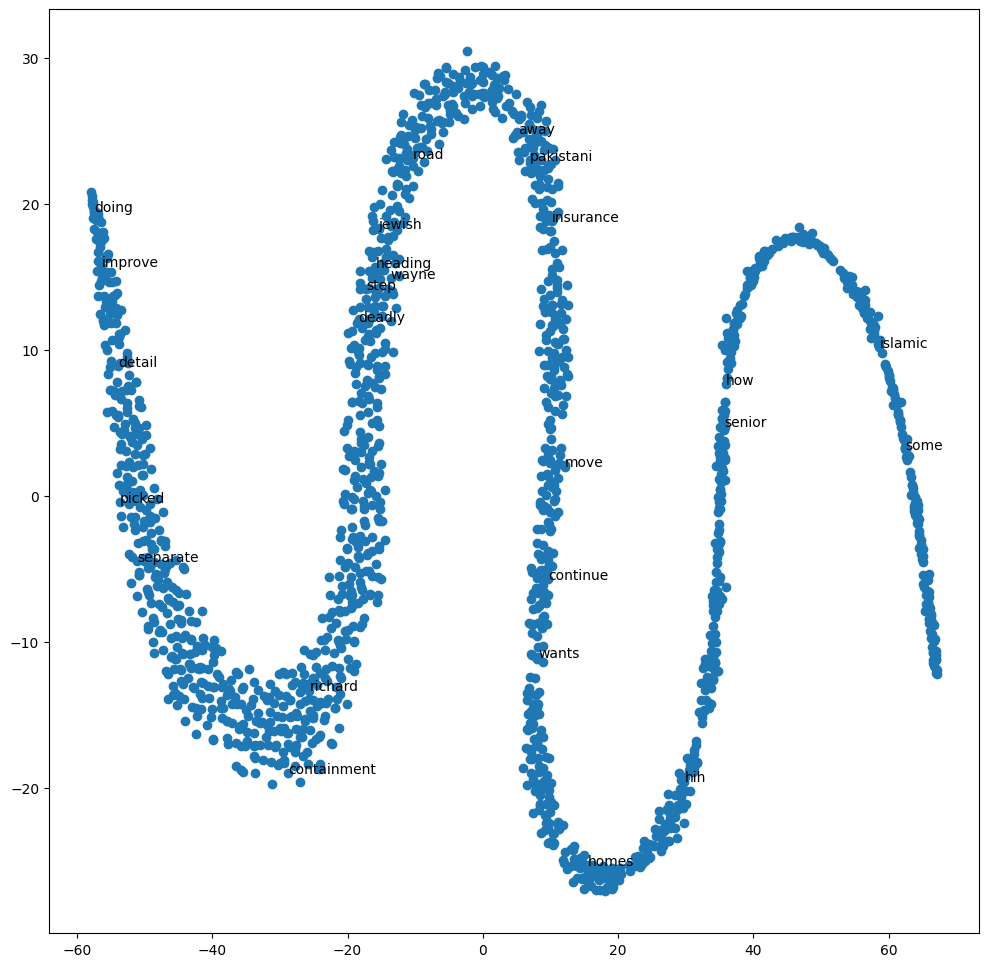

In [28]:
def plot_with_matplotlib(x_vals, y_vals, labels):
    import matplotlib.pyplot as plt
    import random

    random.seed(0)
    plt.figure(figsize=(12, 12))
    plt.scatter(x_vals, y_vals)

    # Label a random subsample of points so the plot stays readable
    indices = list(range(len(labels)))
    selected_indices = random.sample(indices, min(25, len(indices)))
    for i in selected_indices:
        plt.annotate(labels[i], (x_vals[i], y_vals[i]))
    plt.show()

plot_with_matplotlib(x_vals, y_vals, labels)

## Conclusion

This notebook walked through training a Word2Vec model with Gensim,
evaluating it, saving/reloading it, resuming training, and visualizing the
learned embeddings.

For the same algorithm implemented **without** Gensim — every gradient
written by hand in NumPy — see the companion `word2vec-from-scratch` repo.
For the same algorithm in **TensorFlow/Keras**, see `word2vec-tensorflow`.
